In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder.appName("UMAP").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/23 09:30:20 WARN Utils: Your hostname, Evelyn-Nguyen.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/09/23 09:30:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/homebrew/opt/apache-spark/libexec/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/23 09:30:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
cicids = spark.read.parquet("/Users/thonph/Desktop/KLTN/data/processed/clean_cicids.parquet")
unsw = spark.read.parquet("/Users/thonph/Desktop/KLTN/data/processed/clean_unsw.parquet")

In [4]:
unsw.printSchema()
cicids.printSchema()

root
 |-- proto: string (nullable = true)
 |-- state: string (nullable = true)
 |-- dur: double (nullable = true)
 |-- sbytes: integer (nullable = true)
 |-- dbytes: integer (nullable = true)
 |-- sttl: integer (nullable = true)
 |-- dttl: integer (nullable = true)
 |-- sloss: integer (nullable = true)
 |-- dloss: integer (nullable = true)
 |-- service: string (nullable = true)
 |-- sload: double (nullable = true)
 |-- dload: double (nullable = true)
 |-- spkts: integer (nullable = true)
 |-- dpkts: integer (nullable = true)
 |-- swin: integer (nullable = true)
 |-- dwin: integer (nullable = true)
 |-- smeansz: integer (nullable = true)
 |-- dmeansz: integer (nullable = true)
 |-- trans_depth: integer (nullable = true)
 |-- res_bdy_len: integer (nullable = true)
 |-- sjit: double (nullable = true)
 |-- djit: double (nullable = true)
 |-- sintpkt: double (nullable = true)
 |-- dintpkt: double (nullable = true)
 |-- tcprtt: double (nullable = true)
 |-- is_sm_ips_ports: integer (nullable

In [5]:
from pyspark.sql import DataFrame
import pyspark.sql.functions as F

def pyspark_prep_for_umap(df: DataFrame, target_col: str, max_rows_per_class: int = 5000) -> DataFrame:

    thong_ke = df.groupBy(target_col).count().collect()
    tyle_lay_mau = {}
    
    print("--- Phân bổ sau khi lấy mẫu ---")
    for row in thong_ke:
        nhan = row[target_col]
        sl = row['count']
        tyle = 1.0 if sl <= max_rows_per_class else max_rows_per_class / sl
        tyle_lay_mau[nhan] = tyle
        
        sl_sau_khi_cat = int(sl * tyle)
        print(f"Nhãn '{nhan}': {sl_sau_khi_cat} dòng")
        
    df_sampled = df.sampleBy(col=target_col, fractions=tyle_lay_mau, seed=42)
    
    return df_sampled, df

In [6]:
unsw_sample, unsw = pyspark_prep_for_umap(unsw, 'label')

--- Phân bổ sau khi lấy mẫu ---
Nhãn '1': 5000 dòng
Nhãn '0': 5000 dòng


In [8]:
cicids_sample, cicids = pyspark_prep_for_umap(cicids, 'binary_label')

--- Phân bổ sau khi lấy mẫu ---
Nhãn '1': 5000 dòng
Nhãn '0': 5000 dòng


In [9]:
import pandas as pd
import umap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

def encode_and_run_umap(df_pandas: pd.DataFrame, target_col: str):
    print("\nĐang chuẩn hóa dữ liệu...")
    
    # Tách Features (X) và Label (y)
    y = df_pandas[target_col]
    X = df_pandas.drop(columns=[target_col])

    cols_to_drop = [c for c in ['label', 'attack_cat'] if c in X.columns]
    X = X.drop(columns=cols_to_drop)

    numeric_cols = X.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ])
    
    # Thực thi biến đổi dữ liệu
    X_processed = preprocessor.fit_transform(X)
    
    print(f"Kích thước ma trận sau khi mã hóa: {X_processed.shape}")
    print("Đang tính toán UMAP...")
    
    # Chạy UMAP
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_processed)
    
    # Trực quan hóa
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=y, 
        palette='tab20', 
        s=10, 
        alpha=0.8,
        edgecolor=None
    )
    plt.title(f"UMAP Projection (Target: {target_col})", fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
    plt.tight_layout()
    plt.show()
    
    return embedding

/Users/thonph/Desktop/KLTN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/homebrew/opt/apache-spark/libexec/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/23 09:34:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
/Users/thonph/Desktop/KLTN/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Đang chuẩn hóa dữ liệu...
Kích thước ma trận sau khi mã hóa: (10085, 177)
Đang tính toán UMAP...


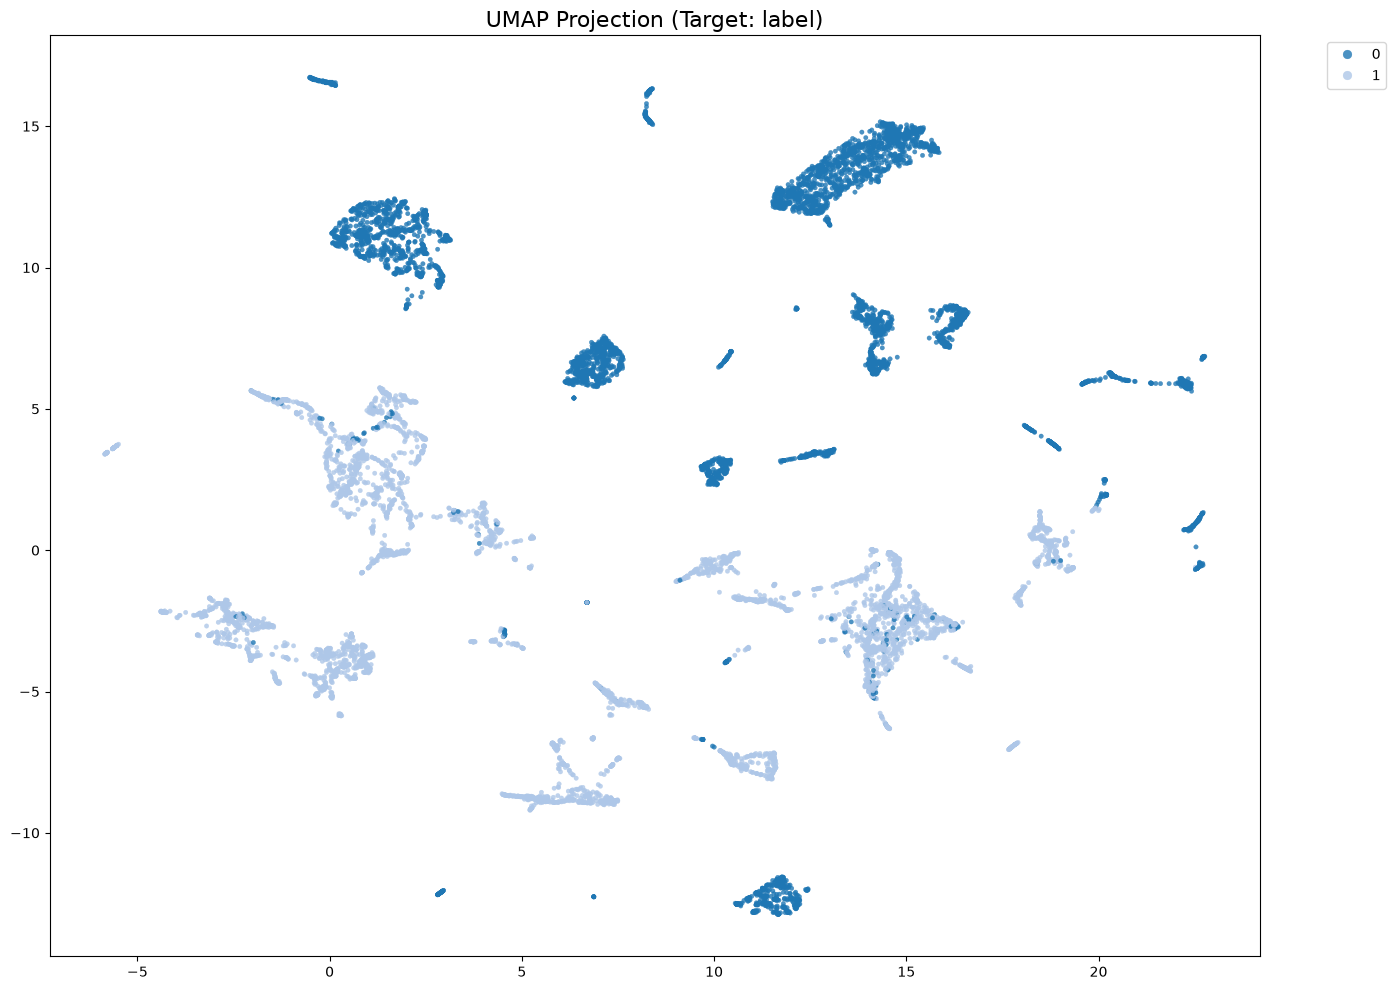

/opt/homebrew/opt/apache-spark/libexec/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/thonph/Desktop/KLTN/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Đang chuẩn hóa dữ liệu...
Kích thước ma trận sau khi mã hóa: (10043, 70)
Đang tính toán UMAP...


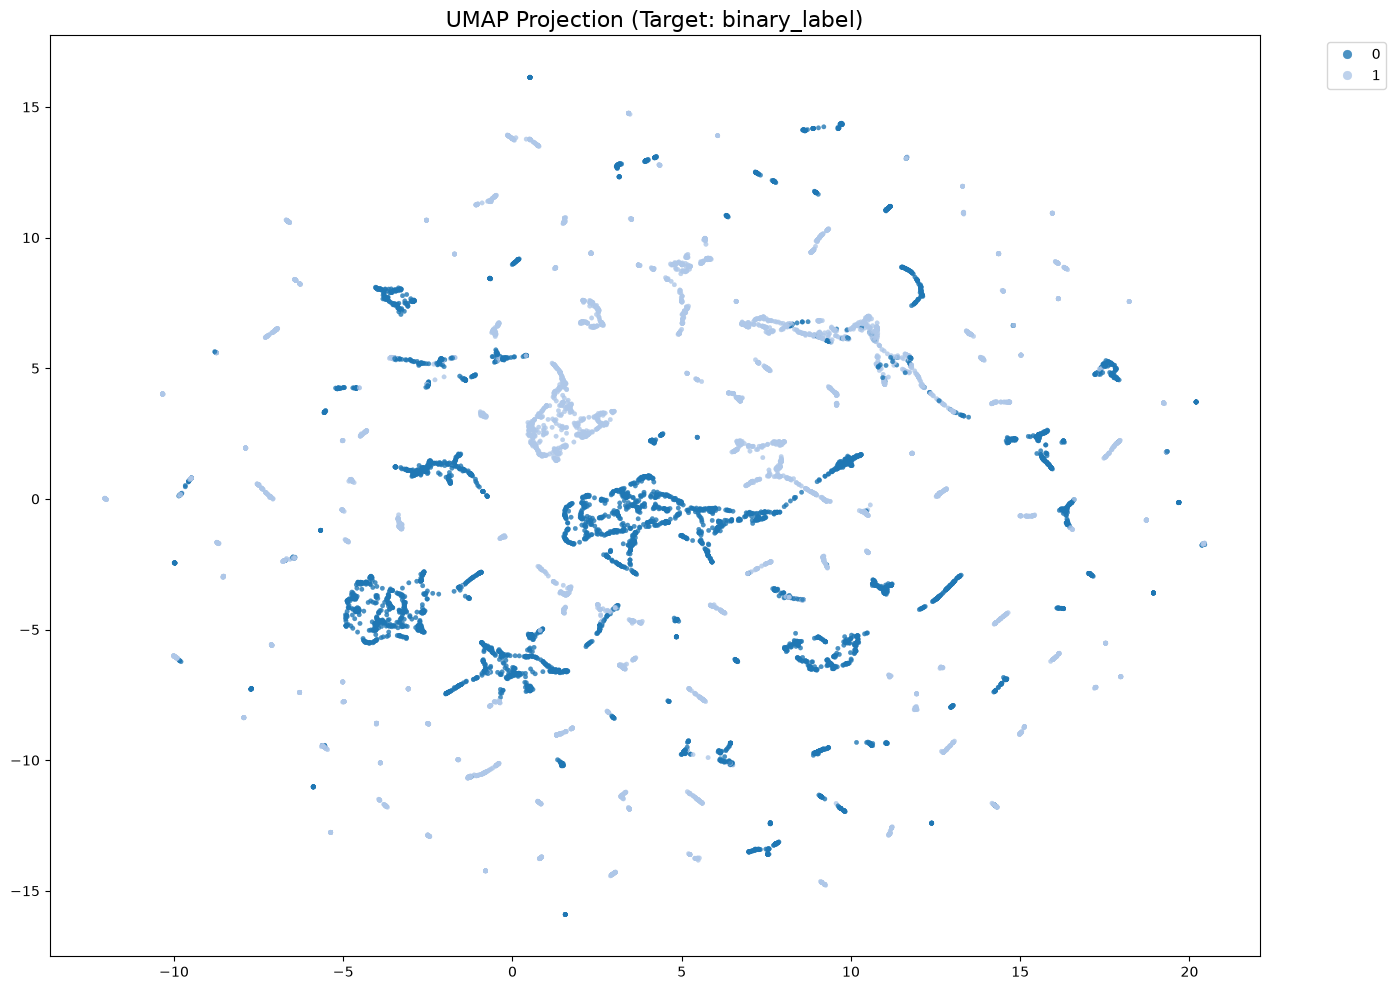

/opt/homebrew/opt/apache-spark/libexec/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()



Đang chuẩn hóa dữ liệu...
Kích thước ma trận sau khi mã hóa: (10085, 177)
Đang tính toán UMAP...


/Users/thonph/Desktop/KLTN/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


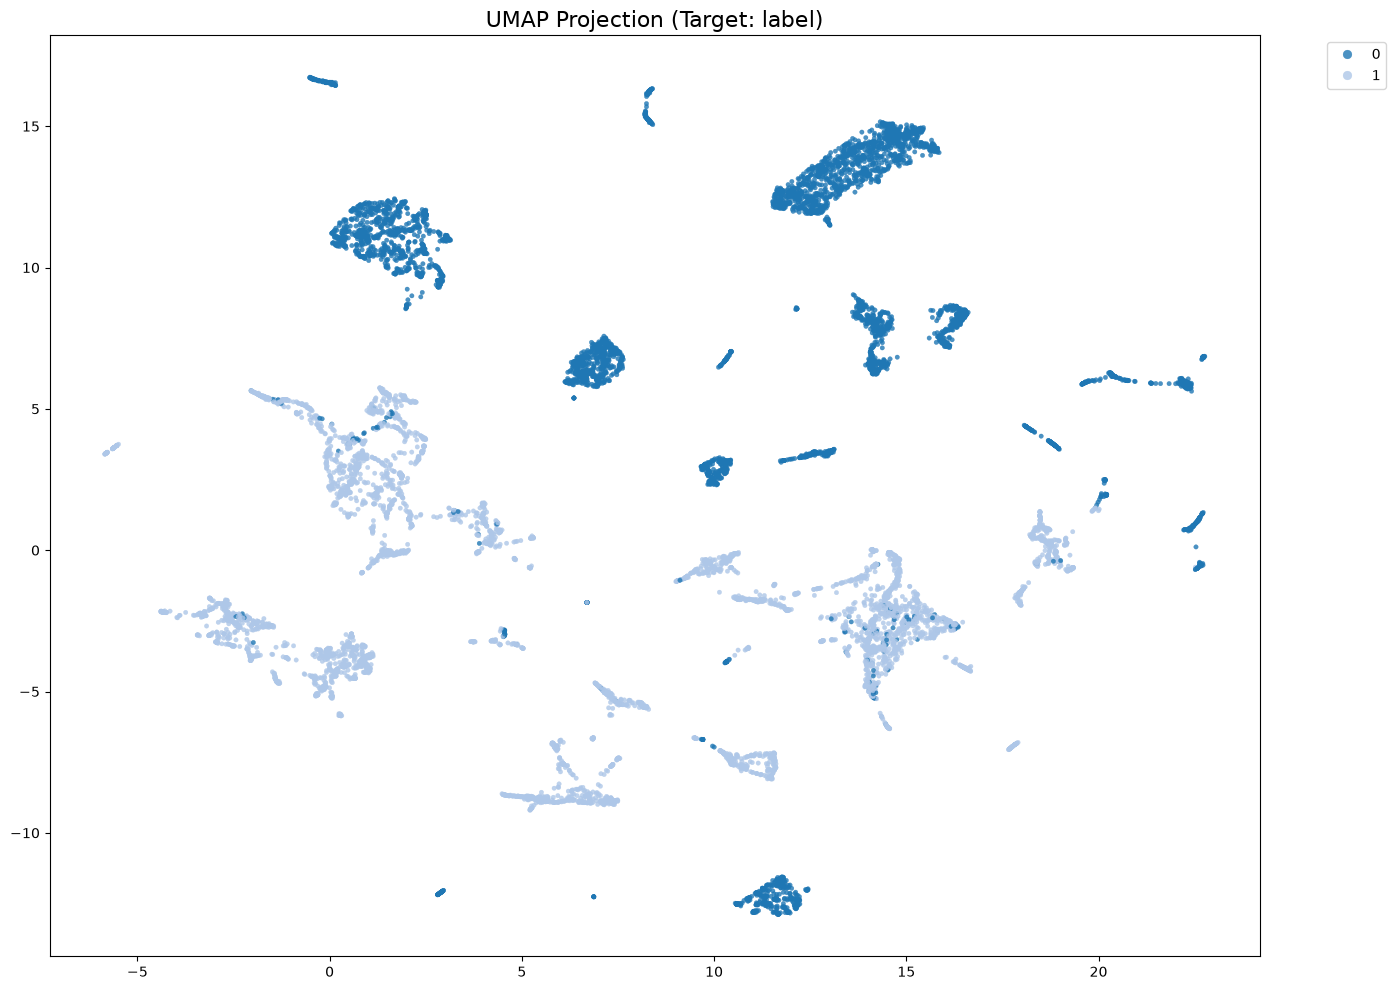

26/09/23 21:09:59 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1024438 ms exceeds timeout 120000 ms
26/09/23 21:09:59 WARN SparkContext: Killing executors is not supported by current scheduler.
26/09/23 21:10:07 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.stor

In [13]:
df_cicids_pd = cicids_sample.toPandas()
embedding_2 = encode_and_run_umap(df_cicids_pd, target_col="binary_label")
df_unsw_pd = unsw_sample.toPandas()
embedding_1 = encode_and_run_umap(df_unsw_pd, target_col="label")

In [ ]:
spark.stop()